# 🟢 SECTION 1 — Why Do We Need Data Augmentation?
## 📖 Primary Reference

ImageNet Classification with Deep Convolutional Neural Networks
Alex Krizhevsky, Ilya Sutskever, Geoffrey Hinton (NeurIPS 2012)

This paper (AlexNet) demonstrated that large-scale supervised deep learning critically depends on:

Large datasets

Strong regularization

Data augmentation

They explicitly state that data augmentation was essential to reduce overfitting.

## 1.1 The Statistical Perspective

To understand why Data Augmentation is necessary,
we must first understand what supervised learning is trying to do
from a statistical viewpoint.

---

### The Learning Problem

In supervised learning, we assume that data comes from
an unknown probability distribution:

    P(x, y)

where:

- x represents the input (for example, an image),
- y represents the label (for example, "cat"),
- P(x, y) is the true but unknown data-generating distribution.

Our goal is to learn a function:

    f(x; θ)

where:

- f is the model (e.g., a neural network),
- θ represents the model parameters (weights),
- f(x; θ) outputs a prediction.

---

### Expected Risk (True Objective)

Ideally, we want to minimize the **Expected Risk**:

    R(f) = E_{(x,y) ~ P} [ L(f(x), y) ]

Let us explain each component carefully:

- R(f): the expected risk (also called true risk)
- E_{(x,y) ~ P}: expectation over the true data distribution
- L(f(x), y): the loss function measuring prediction error

The loss function L could be:
- Cross-entropy (for classification)
- Mean squared error (for regression)

So in words:

R(f) is the average prediction error of the model
over all possible data drawn from the true distribution.

---

### The Fundamental Problem

We do NOT know P(x, y).

We only have a finite training dataset:

    D = {(x₁, y₁), (x₂, y₂), ..., (xₙ, yₙ)}

where:

- n is the number of training samples,
- each (xᵢ, yᵢ) is one observed example.

Because we do not know P,
we cannot compute the true expected risk R(f).

---

### Empirical Risk (What We Actually Minimize)

Instead, we minimize the **Empirical Risk**:

    R_emp(f) = (1/n) Σ L(f(xᵢ), yᵢ)

Let us explain this:

- R_emp(f): empirical risk
- (1/n): average over the dataset
- Σ: summation over all training samples
- L(f(xᵢ), yᵢ): loss on sample i

So empirical risk is simply:

the average training error.

---

### The Generalization Gap

If the model is very flexible (like deep neural networks),
it can make:

    R_emp(f) → 0

by memorizing the training data.

However, this does NOT guarantee:

    R(f) is small.

The difference:

    R(f) − R_emp(f)

is called the **generalization gap**.

When this gap is large,
the model overfits.

---

### Why Does Overfitting Happen?

Overfitting happens when:

- The model capacity is high
- The dataset size n is relatively small
- The training samples do not sufficiently represent P(x, y)

In modern deep learning:

Number of parameters >> Number of training samples (often)

This makes overfitting extremely likely.

---

### Where Data Augmentation Enters

Data Augmentation increases the effective size
and diversity of the training dataset.

If we apply a transformation T such that:

    y remains unchanged under T

then we generate new valid samples:

    (T(x), y)

This helps the empirical distribution better approximate
the true distribution P(x, y).

As a result:

- The empirical risk becomes more representative
- The generalization gap decreases
- Overfitting is reduced

## 🧪 PRACTICAL DEMONSTRATION (Using CIFAR-10)

Although AlexNet was trained on ImageNet,
for teaching purposes we use CIFAR-10, which is small and manageable.

CIFAR-10 contains:

60,000 images

10 classes

32×32 RGB images

## Load Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

d:\ProgramData\anaconda3\envs\tf_gpu\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
d:\ProgramData\anaconda3\envs\tf_gpu\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 376s 2us/step
Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)


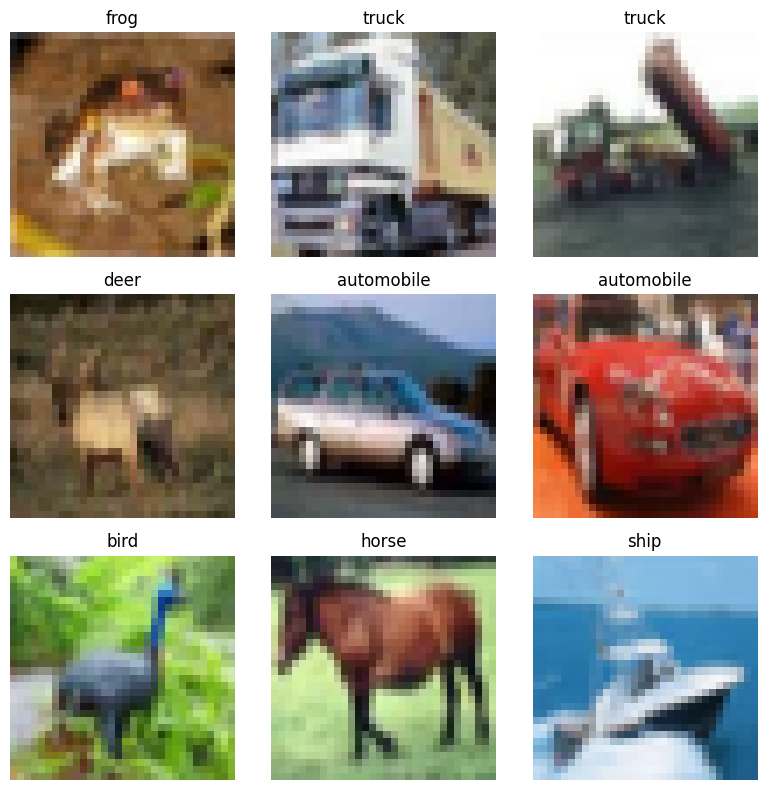

In [2]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Train a CNN WITHOUT Augmentation

We now intentionally train a model without augmentation
to observe overfitting.

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train/255.0, y_train,
    epochs=10,
    validation_data=(X_test/255.0, y_test),
    batch_size=64
)

C:\Users\ali_a\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.3730 - loss: 1.7253 - val_accuracy: 0.5701 - val_loss: 1.2132
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5952 - loss: 1.1570 - val_accuracy: 0.6287 - val_loss: 1.0678
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.6582 - loss: 0.9911 - val_accuracy: 0.6713 - val_loss: 0.9552
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.6936 - loss: 0.8891 - val_accuracy: 0.6835 - val_loss: 0.9192
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.7180 - loss: 0.8088 - val_accuracy: 0.7066 - val_loss: 0.8697
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7456 - loss: 0.7336 - val_accuracy: 0.7030 - val_loss: 0.8606
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7670 - loss: 0.6723 - val_accuracy: 0.6999 - val_loss: 0.8764
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7846 - loss: 0.6235 - 

## Plot Training vs Validation Accuracy

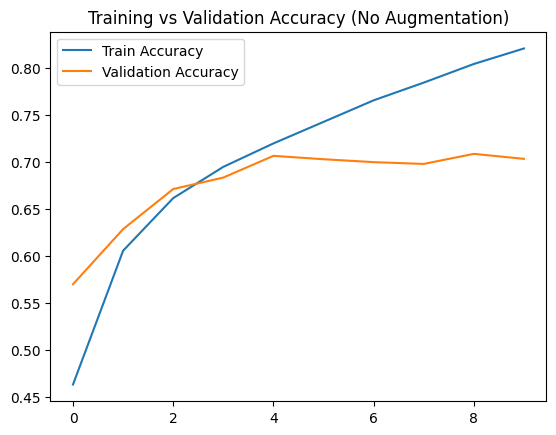

In [4]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy (No Augmentation)")
plt.show()